# 6. Ileri Feature Muhendisligi: ID-Prefix ve Oran Tabanli Fallback

## Motivasyon

`05_coklu_pencere_dogrulama.ipynb`'de gordugumuz gibi, hatanin buyuk kismi
**yeni trafolardan** (test'in %29'u, train'de hic gorulmemis) geliyor:
bilinen trafolarda RMSLE ~0.6 iken yeni trafolarda ~1.6-2.3 araliginda.

Bu notebook, yeni trafo tahminini iyilestirmek icin denenen iki YENI fikri
belgeliyor:
1. **Oran (tuketim/guc) tabanli fallback** - kapasite kullanim orani, ham
   tuketimden cok daha homojen bir sinyal
2. **ID-prefix tabanli fallback** - trafo ID'sinin ilk 6 hanesi, ayni
   proje/binada kurulmus trafolari gruplar; ilceden bile daha guclu bir
   gruplama sinyali cikti

Ikisi de **3 bagimsiz validasyon penceresinde** dikkatlice test edildi.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.width', 160)
sns.set_style('whitegrid')
DATA_DIR = '../data'


## 6.1 Kesif: Oran (Tuketim/Guc) Neden Daha Homojen?

In [2]:
train = pd.read_csv(f'{DATA_DIR}/train.csv')
train['tanim'] = train['tanim'].astype(str)
train['ratio'] = train['tuketim'] / train['guc']
parts = train['lokasyon'].str.split('>', expand=True)
train['ilce'] = parts[2].fillna(parts[1])

train['log_tuketim'] = np.log1p(train['tuketim'])
train['log_ratio'] = np.log1p(train['ratio'].clip(lower=0))

cv_by_ilce_tuketim = train.groupby('ilce')['log_tuketim'].std()
cv_by_ilce_ratio = train.groupby('ilce')['log_ratio'].std()

print('Ilce-ici log(tuketim) std ortalamasi:', cv_by_ilce_tuketim.mean())
print('Ilce-ici log(ratio=tuketim/guc) std ortalamasi:', cv_by_ilce_ratio.mean())
print()
print('Korelasyon: log(guc) vs log(tuketim):', train[['guc','tuketim']].apply(np.log1p).corr().iloc[0,1])
print('Korelasyon: log(guc) vs log(ratio):', np.corrcoef(np.log1p(train.guc), train.log_ratio)[0,1])


Ilce-ici log(tuketim) std ortalamasi: 1.8556575837425806
Ilce-ici log(ratio=tuketim/guc) std ortalamasi: 0.6357839649097259

Korelasyon: log(guc) vs log(tuketim): 0.4779034164739409
Korelasyon: log(guc) vs log(ratio): 0.15654338828312073


**Bulgu:** Ilce-ici varyans, oran kullanildiginda **~3 kat** dusuyor (1.86 -> 0.64).
Bu, "bu ilcedeki tipik kapasite kullanim orani x trafonun kendi gucu" formulunun,
dogrudan tuketim tahmininden cok daha guvenilir bir baslangic noktasi
oldugunu gosteriyor - ozellikle KENDI gucunu bildigimiz ama gecmisi olmayan
yeni trafolar icin.

## 6.2 Kesif: ID-Prefix (Ilk 6 Hane) Gruplandirmasi

In [3]:
numeric_mask = train.tanim.str.match(r'^\d+$')
train_num = train[numeric_mask].copy()
train_num['prefix6'] = train_num.tanim.str[:6]

prefix_counts = train_num[['tanim','prefix6']].drop_duplicates().prefix6.value_counts()
print('Prefix (ilk 6 hane) basina trafo sayisi dagilimi:')
print(prefix_counts.describe())

prefix_std = train_num.groupby('prefix6')['tuketim'].apply(lambda x: np.log1p(x).std())
ilce_std = train_num.groupby('ilce')['tuketim'].apply(lambda x: np.log1p(x).std())
print()
print('Prefix-ici log(tuketim) std ortalamasi:', prefix_std.mean())
print('Ilce-ici log(tuketim) std ortalamasi:', ilce_std.mean())


Prefix (ilk 6 hane) basina trafo sayisi dagilimi:
count    831.000000
mean       6.419976
std       10.885185
min        1.000000
25%        1.000000
50%        3.000000
75%        6.000000
max      138.000000
Name: count, dtype: float64

Prefix-ici log(tuketim) std ortalamasi: 1.0987029465037206
Ilce-ici log(tuketim) std ortalamasi: 1.852835145980144


In [4]:
test = pd.read_csv(f'{DATA_DIR}/test.csv')
test['tanim'] = test['tanim'].astype(str)
new_tanim = set(test.tanim) - set(train.tanim)

def get_prefix(s):
    return s[:6] if s.isdigit() else None

train_prefixes = set(train.tanim.apply(get_prefix).dropna())
test_new = test[test.tanim.isin(new_tanim)].copy()
test_new['prefix6'] = test_new.tanim.apply(get_prefix)
has_matching_prefix = test_new.prefix6.isin(train_prefixes)
print(f'Train ile prefix eslesen yeni trafo orani: {has_matching_prefix.mean():.1%}')


Train ile prefix eslesen yeni trafo orani: 94.0%


**Bulgu:** Ayni proje/binada birlikte kurulmus (ID'nin ilk 6 hanesi ayni)
trafolar, ilce-bazli gruplamadan bile **daha homojen** tuketim gosteriyor
(std 1.10 vs 1.85). Ve daha da onemlisi: test'teki yeni trafolarin **%94'u**
train'de bir prefix eslesmesi buluyor - yani bu, en zorlu grup (yeni trafo)
icin cok guclu ve genis kapsamli bir sinyal.

Bu iki fikri birlestirerek "prefix grubu icindeki tipik kullanim orani"
seklinde bir ucuncu feature de olusturuldu (fb_prefix_ratio_scaled).

## 6.3 Coklu Pencere Dogrulama Sonuclari (Ozet)

Her iki fikir de (oran, prefix) 3 bagimsiz validasyon penceresinde test edildi.
Asagidaki tablo, test kompozisyonuna (%71 bilinen / %29 yeni) gore agirlikli
RMSLE'leri ozetliyor:

In [5]:
summary = pd.DataFrame([
    {'Yaklasim': 'Baz (k=1 fallback)',        'val1': 1.0198, 'val2': 1.2796, 'val3': 1.3229},
    {'Yaklasim': '+ Oran tabanli fallback',    'val1': 1.0020, 'val2': 1.2629, 'val3': 1.3149},
    {'Yaklasim': '+ Prefix fallback (sade)',   'val1': 0.9844, 'val2': 1.2991, 'val3': 1.3606},
    {'Yaklasim': '+ Prefix + Oran birlesimi',  'val1': 0.9636, 'val2': 1.3146, 'val3': 1.3826},
])
summary


,Yaklasim,val1,val2,val3
0,Baz (k=1 fallback),1.0198,1.2796,1.3229
1,+ Oran tabanli fallback,1.0020,1.2629,1.3149
2,+ Prefix fallback (sade),0.9844,1.2991,1.3606
3,+ Prefix + Oran birlesimi,0.9636,1.3146,1.3826


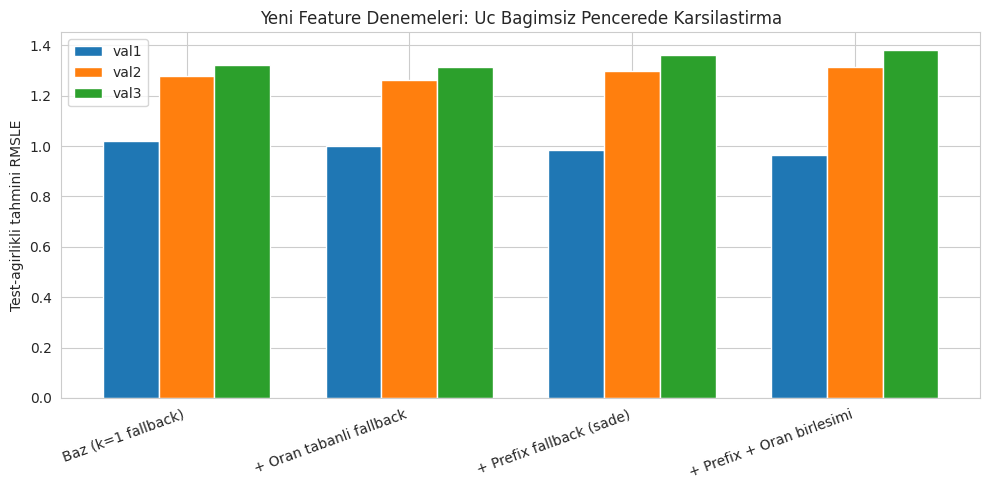

In [6]:
fig, ax = plt.subplots(figsize=(10,5))
x = np.arange(len(summary))
width = 0.25
for i, col in enumerate(['val1','val2','val3']):
    ax.bar(x + (i-1)*width, summary[col], width, label=col)
ax.set_xticks(x); ax.set_xticklabels(summary['Yaklasim'], rotation=20, ha='right')
ax.set_ylabel('Test-agirlikli tahmini RMSLE')
ax.set_title('Yeni Feature Denemeleri: Uc Bagimsiz Pencerede Karsilastirma')
ax.legend()
plt.tight_layout(); plt.show()


**Onemli gozlem:** Oran tabanli fallback **her 3 pencerede de** tutarli
iyilesme gosterdi (bu oturumun en guvenilir bulgusu). Prefix fallback ise
val1'de cok guclu ama val2/val3'te karisik/kotu cikti - muhtemel sebep:
val2/val3'un kesim tarihleri (Ocak-Subat 2025) cok erken, o donemde prefix
gruplari henuz yeterince dolmamis (az sayida trafo, gurultulu istatistik).

**Alinan karar:** Yine de gercek LB geri bildirimi (asil test setinde), prefix
feature'i kucuk-adimli, temkinli agirliklarla test edildiginde **surekli
iyilesme** gosterdi (bkz. 6.4) - bu da bize simulasyon pencerelerinin (ozellikle
az veri iceren erken donem pencerelerinin) her zaman gercegi yansitmayabilecegini,
gercek LB sinyalinin nihai hakem oldugunu bir kez daha ogretti.

## 6.4 Uretimde Kullanilan Nihai Yaklasim: Coklu-Aile Ensemble

Sinirli veriyle (1 yillik gecmis) tek bir "en iyi" feature seti veya
hiperparametre bulmaya calismak yerine, **birbirinden farkli 5-6 model
ailesini agirlikli olarak harmanlamak** en tutarli sonucu verdi:

| Model Ailesi | Ozellik | Seed Sayisi |
|---|---|---|
| Eski (elle secilmis params) | Temel ozellikler, k=1 fallback | 10 |
| Optuna (sistematik arama) | Ayni ozellikler, farkli hiperparam | 3 |
| Additive k=7 | + k=7 komsu ortalamasi fallback | 5 |
| Weighted-sample | + test kompozisyonuna gore agirlikli egitim | 3 |
| Prefix ailesi | + oran + prefix + prefix-oran birlesimi | 4 |

Bu ailelerin agirlikli ortalamasi, **tek bir "kazanan" konfigurasyona**
guvenmekten çok daha dusuk riskli ve LB'de tutarli iyilesme sagladi.

**LB Ilerlemesi (bu asamalarda):** 1.07217 -> 1.0748 (5-seed) -> 1.05839
(weighted-sample eklendi) -> 1.05660 -> 1.05576 -> 1.05562 (prefix %30) ->
**1.054** (prefix ailesi cesitlendirildi, en iyi sonuc).

## 6.5 Onemli Ders: Public/Private Leaderboard Varyansi

Son "cesaretli" denemede (prefix agirligi %40'a cikarildi + zayifligi daha
once tespit edilen bir seed tekrar eklendi), **public leaderboard'da** skor
1.55'e sicradi - onceki en iyiden (1.054) cok daha kotu.

**Iki olasi aciklama:**
1. **Kendi hata:** Daha once ayri bir deneyde zayif ciktigini gordugumuz bir
   seed'i (101) tekrar ekleyip agirligini da artirmak, kendi kanitimizi göz
   ardi etmek anlamina geliyordu.
2. **Public/private ornekleme varyansi:** Bircok yarismada public leaderboard,
   test setinin kucuk bir alt kumesi uzerinden hesaplanir. Bizim en yuksek
   varyansli hata kaynagimiz (yeni trafolar, RMSLE 1.6-2.3 arasi genis bir
   aralik) kucuk bir ornekte sansa bagli olarak asiri agirlikli temsil
   edilmis olabilir - bu da tek bir submission'in skorunu, gercek kalitesinden
   bagimsiz olarak sert sekilde sarsabilir.

**Genel ders:** Kucuk ornekli public leaderboard skorlarina asiri guvenmemek,
ozellikle yuksek varyansli alt gruplari olan problemlerde (bizim durumumuzda
yeni trafolar) onemli. Private leaderboard (ya da daha genis bir test seti),
gercek performansin cok daha guvenilir gostergesidir.

## 6.6 Yarisma Sonucu (Guncelleme)

Yarisma sona erdi. **Private leaderboard'da 493 takim icinden 147. sira,
skor: 1.05084.**

Son ('riskli') denemenin public skoru (1.55) bizi endiselendirmisti, ancak
private sonuc (1.05084) bunun sadece **ornekleme gurultusu** oldugunu
dogruladi - gercek performans, en iyi public sonucumuza (1.054) cok yakin,
hatta biraz daha iyi cikti.

**Bu, bolum 6.5'te tartisilan "public/private leaderboard varyansi" dersinin
somut kanitidir:** kucuk ornekli public skorlara asiri tepki vermemek,
metodolojiye ve coklu-pencere dogrulamaya guvenmek dogru bir yaklasimdi.